In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../raw/maharashtra_prices.csv")


In [3]:
df

,report_date,state_id,state_name,market_id,market_name,commodity_id,commodity_name,total_arrivals,market_center,arrivals,unit_of_arrivals,variety,grade,min_price,max_price,modal_price,unit_of_price
0,2021-01-01,20,Maharashtra,1349,APMC Chimur,15,Cotton,192.0,APMC Chimur,192.0,Metric Tonnes,Other,FAQ,5550.0,5625.0,5575.0,Rs./Quintal
1,2021-01-01,20,Maharashtra,1349,APMC Chimur,2,Paddy(Common),48.0,APMC Chimur,48.0,Metric Tonnes,Other,FAQ,2150.0,2250.0,2175.0,Rs./Quintal
2,2021-01-01,20,Maharashtra,1933,APMC Rajura,13,Soyabean,14.0,APMC Rajura,14.0,Metric Tonnes,Yellow,FAQ,3895.0,4210.0,4095.0,Rs./Quintal
3,2021-01-01,20,Maharashtra,2048,APMC Aarni,45,Red gram/Arhar/Tur(whole),14.0,APMC Aarni,14.0,Metric Tonnes,Other,FAQ,5500.0,5800.0,5600.0,Rs./Quintal
4,2021-01-01,20,Maharashtra,1901,APMC Aatpadi,160,Pomegranate,50.0,APMC Aatpadi,50.0,Metric Tonnes,Other,FAQ,2000.0,40000.0,21000.0,Rs./Quintal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967776,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),131,Cucumbar(Kheera),1.2,Pune(Pimpri),1.2,Metric Tonnes,Other,Local,1400.0,2200.0,1800.0,Rs./Quintal
1967777,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),23,Onion,3.3,Pune(Pimpri),3.3,Metric Tonnes,Local,Local,2500.0,4700.0,3600.0,Rs./Quintal
1967778,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),133,Raddish,600.0,Pune(Pimpri),600.0,Metric Tonnes,Other,Local,7.0,9.0,8.0,Rs./Quintal
1967779,2026-09-13,20,Maharashtra,2148,Pune(Pimpri),290,Spinach,650.0,Pune(Pimpri),650.0,Metric Tonnes,Other,Local,7.0,9.0,8.0,Rs./Quintal


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967781 entries, 0 to 1967780
Data columns (total 17 columns):
 #   Column            Dtype  
---  ------            -----  
 0   report_date       object 
 1   state_id          int64  
 2   state_name        object 
 3   market_id         int64  
 4   market_name       object 
 5   commodity_id      int64  
 6   commodity_name    object 
 7   total_arrivals    float64
 8   market_center     object 
 9   arrivals          float64
 10  unit_of_arrivals  object 
 11  variety           object 
 12  grade             object 
 13  min_price         float64
 14  max_price         float64
 15  modal_price       float64
 16  unit_of_price     object 
dtypes: float64(5), int64(3), object(9)
memory usage: 255.2+ MB


In [5]:
df.isnull().sum()

report_date           0
state_id              0
state_name            0
market_id             0
market_name           0
commodity_id          0
commodity_name        0
total_arrivals        0
market_center         0
arrivals              0
unit_of_arrivals      0
variety               0
grade                 0
min_price            46
max_price             0
modal_price         374
unit_of_price         0
dtype: int64

In [6]:
df.shape

(1967781, 17)

In [7]:
df.dtypes

report_date          object
state_id              int64
state_name           object
market_id             int64
market_name          object
commodity_id          int64
commodity_name       object
total_arrivals      float64
market_center        object
arrivals            float64
unit_of_arrivals     object
variety              object
grade                object
min_price           float64
max_price           float64
modal_price         float64
unit_of_price        object
dtype: object

In [8]:
df.head()

,report_date,state_id,state_name,market_id,market_name,commodity_id,commodity_name,total_arrivals,market_center,arrivals,unit_of_arrivals,variety,grade,min_price,max_price,modal_price,unit_of_price
0,2021-01-01,20,Maharashtra,1349,APMC Chimur,15,Cotton,192.0,APMC Chimur,192.0,Metric Tonnes,Other,FAQ,5550.0,5625.0,5575.0,Rs./Quintal
1,2021-01-01,20,Maharashtra,1349,APMC Chimur,2,Paddy(Common),48.0,APMC Chimur,48.0,Metric Tonnes,Other,FAQ,2150.0,2250.0,2175.0,Rs./Quintal
2,2021-01-01,20,Maharashtra,1933,APMC Rajura,13,Soyabean,14.0,APMC Rajura,14.0,Metric Tonnes,Yellow,FAQ,3895.0,4210.0,4095.0,Rs./Quintal
3,2021-01-01,20,Maharashtra,2048,APMC Aarni,45,Red gram/Arhar/Tur(whole),14.0,APMC Aarni,14.0,Metric Tonnes,Other,FAQ,5500.0,5800.0,5600.0,Rs./Quintal
4,2021-01-01,20,Maharashtra,1901,APMC Aatpadi,160,Pomegranate,50.0,APMC Aatpadi,50.0,Metric Tonnes,Other,FAQ,2000.0,40000.0,21000.0,Rs./Quintal


In [9]:
print("Duplicate rows:", df.duplicated().sum())

df["report_date"] = pd.to_datetime(df["report_date"], errors="coerce")
print(df["report_date"].isnull().sum())   # should be 0 after conversion
print(df["report_date"].min(), df["report_date"].max())

Duplicate rows: 0
0
2021-01-01 00:00:00 2026-09-13 00:00:00


In [10]:
same_market = (df["market_name"] == df["market_center"]).mean()
print(f"market_name == market_center: {same_market:.2%}")

same_arrivals = np.isclose(df["arrivals"], df["total_arrivals"]).mean()
print(f"arrivals == total_arrivals: {same_arrivals:.2%}")

# also check the ID columns are truly 1:1 with names (no typos/duplicates under one ID)
print(df.groupby("market_id")["market_name"].nunique().value_counts())
print(df.groupby("commodity_id")["commodity_name"].nunique().value_counts())

market_name == market_center: 100.00%
arrivals == total_arrivals: 96.32%
market_name
1    393
Name: count, dtype: int64
commodity_name
1    142
Name: count, dtype: int64


In [11]:
df = df.drop(columns=["market_center"])

mismatch = df[~np.isclose(df["arrivals"], df["total_arrivals"])]
print(mismatch.shape)
print((mismatch["total_arrivals"] - mismatch["arrivals"]).describe())
mismatch[["report_date","market_name","commodity_name","arrivals","total_arrivals"]].sample(10)

(72510, 16)
count    72510.000000
mean       105.313175
std        267.516048
min          0.050000
25%          2.900000
50%         15.350000
75%         80.475000
max      10789.700000
dtype: float64


,report_date,market_name,commodity_name,arrivals,total_arrivals
1409450,2025-04-21,Lasalgaon(Niphad),Wheat,9.65,19.3
1965820,2026-09-11,APMC Jalana,Bengal Gram(Gram)(Whole),0.60,2.9
1392899,2025-04-07,APMC Dharangaon,Jowar(Sorghum),14.50,29.0
913593,2023-11-22,APMC Chandwad,Onion,416.50,833.0
1424870,2025-05-05,APMC Dhule,Bengal Gram(Gram)(Whole),5.00,10.0
1464194,2025-06-07,APMC Shevgaon,Onion,42.80,128.4
573739,2022-11-09,APMC Pachora,Jowar(Sorghum),7.50,15.0
1866740,2026-06-22,APMC Dhule,Wheat,3.60,13.6
1631883,2025-11-18,APMC Hinganghat,Wheat,1.10,8.4
1592936,2025-10-04,APMC Dhule,Jowar(Sorghum),1.20,2.4


In [13]:
nulls = df[df["min_price"].isnull() | df["modal_price"].isnull()]
print(nulls.shape)
print(nulls["commodity_name"].value_counts().head(10))
print(nulls["market_name"].value_counts().head(10))
nulls[["report_date","market_name","commodity_name","min_price","max_price","modal_price"]].head(10)

(413, 16)
commodity_name
Soyabean                        114
Turmeric                         80
Bengal Gram(Gram)(Whole)         73
Red gram/Arhar/Tur(whole)        51
Wheat                            33
Sesamum(Sesame,Gingelly,Til)     24
Jowar(Sorghum)                   19
Green Gram(Moong)(Whole)          7
Maize                             3
Pomegranate                       3
Name: count, dtype: int64
market_name
Sant Namdev Krushi Bazar, Tal Sengaon Dist Hingoli     219
Shekari Krushi Khajgi Bazar, Arni, Dist Yavatmal       145
Sindi (Selu)                                            26
Perfect Krushi Market Yard, Tal Madha, Dist Solapur      3
APMC Umared                                              2
APMC Kalvan                                              2
APMC Karanja                                             1
APMC Pathari                                             1
APMC Ahilyanagar                                         1
APMC Nasik                                    

,report_date,market_name,commodity_name,min_price,max_price,modal_price
41006,2021-02-23,APMC Karanja,Black Gram(Urd Beans)(Whole),NaN,6405.0,5050.0
60918,2021-03-20,APMC Kalvan,Maize,NaN,1480.0,1452.0
79389,2021-04-13,APMC Manwat,Red gram/Arhar/Tur(whole),NaN,6900.0,6600.0
81335,2021-04-15,APMC Umared,Wheat,NaN,2500.0,2100.0
107818,2021-05-24,APMC Rajura,Bengal Gram(Gram)(Whole),NaN,4720.0,4625.0
119889,2021-06-07,APMC Shahada,Maize,NaN,1543.0,1543.0
136183,2021-06-23,Sindi (Selu),Soyabean,NaN,6400.0,6210.0
140054,2021-06-28,APMC Lasur Station,Maize,NaN,1725.0,1500.0
208943,2021-09-16,APMC Umared,Bengal Gram(Gram)(Whole),NaN,5070.0,5000.0
235287,2021-10-18,APMC Chopda,Wheat,NaN,1875.0,1871.0


In [14]:
df = df.dropna(subset=["min_price", "max_price", "modal_price"])
print(df.shape)

(1967368, 16)


In [15]:
bad_order = df[~((df.min_price <= df.modal_price) & (df.modal_price <= df.max_price))]
print("Bad order rows:", bad_order.shape)
bad_order[["report_date","market_name","commodity_name","min_price","max_price","modal_price"]].head(10)

print("Zero/negative prices:", (df[["min_price","max_price","modal_price"]] <= 0).sum())

Bad order rows: (5, 16)
Zero/negative prices: min_price      0
max_price      0
modal_price    0
dtype: int64


In [16]:
bad_order[["report_date","market_name","commodity_name","min_price","max_price","modal_price"]]

,report_date,market_name,commodity_name,min_price,max_price,modal_price
330145,2022-01-31,APMC Chandur Bazar,Red gram/Arhar/Tur(whole),5500.0,5250.0,5741.0
330268,2022-01-31,APMC Kalamb (Dharashiv),Bengal Gram(Gram)(Whole),4200.0,4500.0,43.0
332007,2022-02-02,APMC Hingoli,Red gram/Arhar/Tur(whole),6135.0,6725.0,5430.0
1802959,2026-04-29,Shri Gajanan Maharaj Khajagi Krushi Utpanna Ba...,Cotton,7200.0,8600.0,6442.0
1932593,2026-08-13,"Cottoncity Agro Foods Pvt Ltd, Dist Yavatmal",Bengal Gram(Gram)(Whole),6000.0,6195.0,5896.0


In [17]:
df = df.drop(bad_order.index)
print(df.shape)

(1967363, 16)


In [18]:
text_cols = ["market_name", "commodity_name", "variety", "grade", "state_name"]
for col in text_cols:
    df[col] = df[col].str.strip()

print(df["market_name"].nunique())

393


In [19]:
sample = df[(df.market_name == "Lasalgaon(Niphad)") & (df.commodity_name == "Onion")]
print(sample.shape)
print(sample["variety"].value_counts())
print(sample["grade"].value_counts())

# pick the dominant variety/grade combo and look at date gaps
top_variety = sample["variety"].value_counts().idxmax()
top_grade = sample["grade"].value_counts().idxmax()
series = sample[(sample.variety == top_variety) & (sample.grade == top_grade)].sort_values("report_date")

dates = series["report_date"]
gaps = dates.diff().dt.days
print(gaps.describe())
print(gaps.value_counts().head(10))

(1721, 16)
variety
Other     1057
Red        556
Unhali     108
Name: count, dtype: int64
grade
FAQ      1208
Local     513
Name: count, dtype: int64
count    796.000000
mean       1.807789
std        4.809005
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       74.000000
Name: report_date, dtype: float64
report_date
1.0     599
2.0     125
3.0      33
4.0      13
5.0       7
7.0       3
6.0       3
13.0      2
8.0       2
68.0      1
Name: count, dtype: int64


In [20]:
# gap stats per (market, commodity) pair, across the whole dataset
gap_stats = (
    df.sort_values("report_date")
      .groupby(["market_name", "commodity_name"])["report_date"]
      .apply(lambda s: s.diff().dt.days.median())
)
print(gap_stats.describe())
print(gap_stats.value_counts().head(10))

# how many (market, commodity) series even have enough history to forecast (say, 100+ points)?
counts = df.groupby(["market_name", "commodity_name"]).size()
print(counts.describe())
print((counts >= 100).sum(), "series with 100+ records")
print((counts >= 365).sum(), "series with 365+ records")

count    4568.000000
mean       30.622373
std       131.944085
min         0.000000
25%         1.000000
50%         2.000000
75%         6.000000
max      1800.000000
Name: report_date, dtype: float64
report_date
1.0     1852
2.0      798
3.0      364
7.0      239
4.0      204
5.0      101
6.0       65
14.0      46
8.0       35
9.0       33
Name: count, dtype: int64
count    4905.000000
mean      401.093374
std       494.335482
min         1.000000
25%        18.000000
50%       163.000000
75%       643.000000
max      2700.000000
dtype: float64
2813 series with 100+ records
1791 series with 365+ records


In [21]:
# filter to reliable series
reliable_pairs = counts[counts >= 365].index  # (market_name, commodity_name) tuples
df_reliable = df.set_index(["market_name", "commodity_name"]).loc[reliable_pairs].reset_index()
print(df_reliable.shape)
print(df_reliable["commodity_name"].nunique(), "commodities")
print(df_reliable["market_name"].nunique(), "markets")

# within these, how many still have multiple variety/grade combos per market+commodity?
vg_counts = df_reliable.groupby(["market_name","commodity_name"])[["variety","grade"]].nunique()
print(vg_counts.describe())

(1703490, 16)
107 commodities
256 markets
           variety        grade
count  1791.000000  1791.000000
mean      1.185371     2.021217
std       0.526640     0.294449
min       1.000000     1.000000
25%       1.000000     2.000000
50%       1.000000     2.000000
75%       1.000000     2.000000
max       6.000000     3.000000


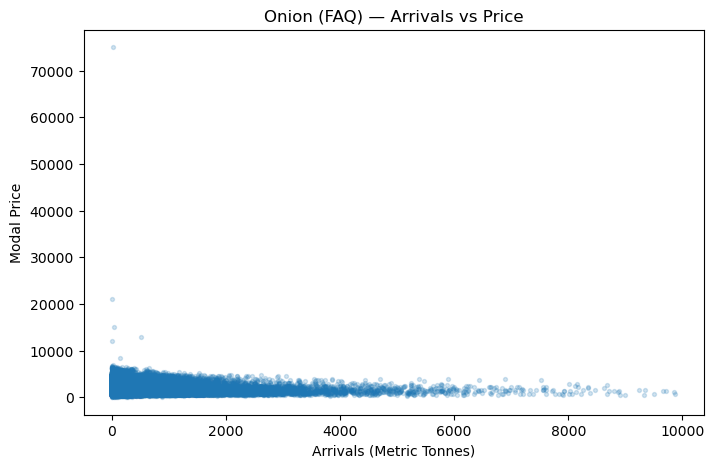

             arrivals  modal_price
arrivals      1.00000     -0.07595
modal_price  -0.07595      1.00000


In [22]:
# use the reliable subset from before
onion = df_reliable[(df_reliable.commodity_name == "Onion") & (df_reliable.grade == "FAQ")]

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(onion["arrivals"], onion["modal_price"], alpha=0.2, s=8)
plt.xlabel("Arrivals (Metric Tonnes)")
plt.ylabel("Modal Price")
plt.title("Onion (FAQ) — Arrivals vs Price")
plt.show()

print(onion[["arrivals","modal_price"]].corr())

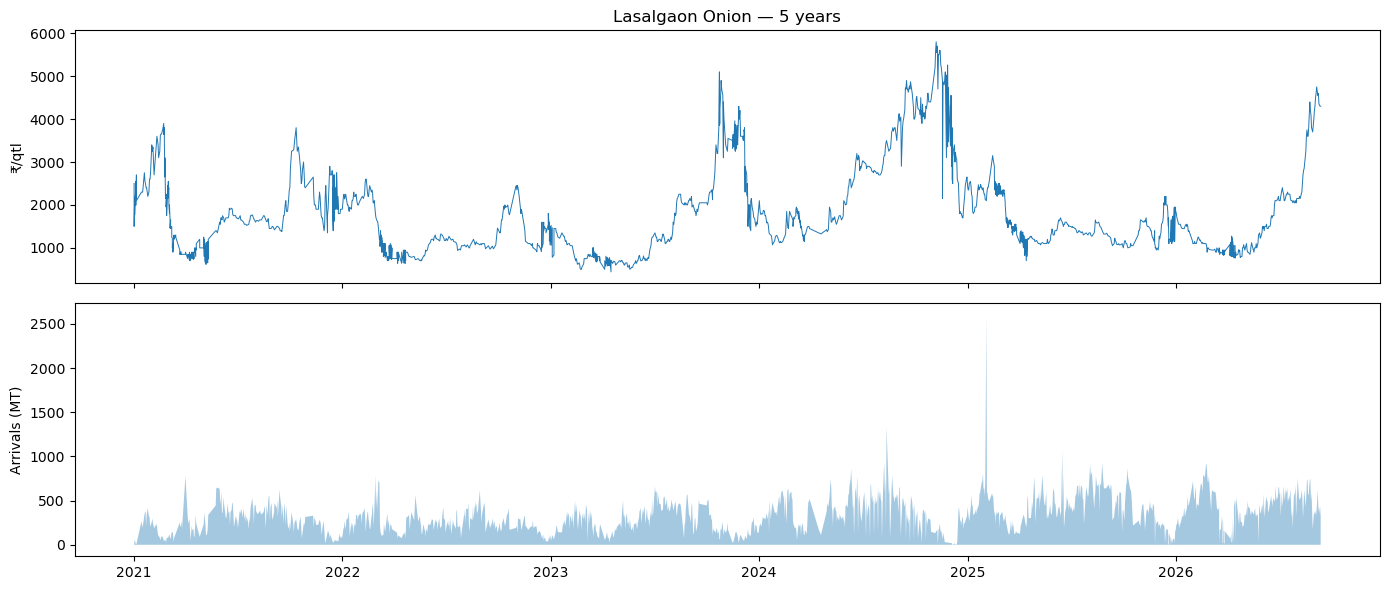

lag  0: r = -0.033
lag  1: r = -0.034
lag  2: r = -0.029
lag  3: r = -0.021
lag  5: r = -0.005
lag  7: r = +0.020
lag 14: r = +0.088


In [23]:

onion_series = df_reliable[
    (df_reliable.commodity_name == "Onion") & 
    (df_reliable.market_name == "Lasalgaon(Niphad)")
].sort_values("report_date")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(onion_series.report_date, onion_series.modal_price, lw=0.7)
axes[0].set_ylabel("₹/qtl"); axes[0].set_title("Lasalgaon Onion — 5 years")
axes[1].fill_between(onion_series.report_date, 0, onion_series.arrivals, alpha=0.4)
axes[1].set_ylabel("Arrivals (MT)"); plt.tight_layout(); plt.show()

# Lagged correlation
for lag in [0, 1, 2, 3, 5, 7, 14]:
    r = onion_series["arrivals"].shift(lag).corr(onion_series["modal_price"])
    print(f"lag {lag:2d}: r = {r:+.3f}")

In [24]:
extreme = df[df["modal_price"] > 100000].sort_values("modal_price", ascending=False)
print(extreme["commodity_name"].value_counts())
extreme[["report_date","market_name","commodity_name","min_price","max_price","modal_price"]].head(20)

commodity_name
Cardamom             861
Cashewnuts           123
Almond(Badam)        112
Cow                   15
She Buffalo           13
Cinamon(Dalchini)      6
Black pepper           3
Chili Red              1
Corriander seed        1
Guar                   1
Pomegranate            1
Mustard                1
Ginger(Dry)            1
Name: count, dtype: int64


,report_date,market_name,commodity_name,min_price,max_price,modal_price
427,2021-01-01,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
96695,2021-05-06,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
136634,2021-06-24,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
135489,2021-06-23,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
134338,2021-06-22,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
131645,2021-06-19,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
130648,2021-06-18,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
129472,2021-06-17,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
128258,2021-06-16,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0
127018,2021-06-15,APMC Mumbai,Cardamom,150000.0,370000.0,350000.0


In [25]:
# per-commodity price capping (99.5th percentile per commodity, not global — 
# since price scales differ wildly by commodity, e.g. Wheat vs Pomegranate)
def cap_outliers(group):
    cap = group["modal_price"].quantile(0.995)
    return group[group["modal_price"] <= cap]

df_reliable = df_reliable.groupby("commodity_name", group_keys=False).apply(cap_outliers)
print(df_reliable.shape)

(1696247, 16)


C:\Users\hp\AppData\Local\Temp\ipykernel_26376\200525608.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reliable = df_reliable.groupby("commodity_name", group_keys=False).apply(cap_outliers)


In [26]:
print(df[df["commodity_name"].isin(["Cow", "She Buffalo"])][["commodity_name","unit_of_price","min_price","max_price","modal_price"]].head(10))

      commodity_name unit_of_price  min_price  max_price  modal_price
3789             Cow      Rs./Unit    35000.0    60000.0      50000.0
3793     She Buffalo      Rs./Unit    30000.0    60000.0      45000.0
12001    She Buffalo      Rs./Unit    20000.0    63000.0      41500.0
12607            Cow      Rs./Unit    25000.0    68000.0      35000.0
18043    She Buffalo      Rs./Unit    20000.0    60000.0      40000.0
18691            Cow      Rs./Unit    25000.0    70000.0      35000.0
22866            Cow      Rs./Unit    30000.0    60000.0      45000.0
22869    She Buffalo      Rs./Unit    35000.0    60000.0      45000.0
25427            Cow      Rs./Unit    20000.0    70000.0      40000.0
30457    She Buffalo      Rs./Unit    20000.0    40000.0      30000.0


In [27]:
df_reliable = df_reliable[df_reliable["unit_of_price"] == "Rs./Quintal"]
print(df_reliable.shape)
print(df_reliable["commodity_name"].nunique(), "commodities remain")

# double check no other stray units exist
print(df_reliable["unit_of_price"].value_counts())

(1650419, 16)
104 commodities remain
unit_of_price
Rs./Quintal    1650419
Name: count, dtype: int64


In [28]:
df_reliable = df_reliable.sort_values(["market_name", "commodity_name", "variety", "grade", "report_date"])

df_reliable["year"] = df_reliable["report_date"].dt.year
df_reliable["month"] = df_reliable["report_date"].dt.month
df_reliable["day_of_week"] = df_reliable["report_date"].dt.dayofweek
df_reliable["week_of_year"] = df_reliable["report_date"].dt.isocalendar().week.astype(int)

# days since this exact series (market+commodity+variety+grade) last reported
grp_keys = ["market_name", "commodity_name", "variety", "grade"]
df_reliable["days_since_last_report"] = (
    df_reliable.groupby(grp_keys)["report_date"].diff().dt.days
)

print(df_reliable[["report_date","market_name","commodity_name","variety","grade","days_since_last_report"]].head(10))
print(df_reliable["days_since_last_report"].describe())

    report_date   market_name commodity_name           variety grade  \
62   2021-03-20  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
96   2021-11-13  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
285  2023-01-27  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
312  2023-03-01  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
313  2023-03-02  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
314  2023-03-03  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
322  2023-03-13  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
401  2023-11-17  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
403  2023-11-18  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   
452  2024-01-30  APMC  Chimur         Cotton  H-4(A) 27mm FIne   FAQ   

     days_since_last_report  
62                      NaN  
96                    238.0  
285                   440.0  
312                    33.0  
313                     1.0  
314                     1.0

In [29]:
import re
double_space = df_reliable["market_name"].str.contains(r"\s{2,}", regex=True, na=False)
print(double_space.sum(), "rows with internal double-spaces in market_name")
print(df_reliable.loc[double_space, "market_name"].unique()[:20])

12154 rows with internal double-spaces in market_name
['APMC  Chimur' 'APMC  Latur' 'APMC  Rajura' 'APMC  VASAI' 'APMC  Yawal']


In [30]:
df_reliable["market_name"] = df_reliable["market_name"].str.replace(r"\s+", " ", regex=True)

In [31]:
for name in ['APMC  Chimur', 'APMC  Latur', 'APMC  Rajura', 'APMC  VASAI', 'APMC  Yawal']:
    single_space = name.replace("  ", " ")
    print(name, "->", (df_reliable["market_name"] == single_space).sum(), "rows already exist as:", single_space)

APMC  Chimur -> 1686 rows already exist as: APMC Chimur
APMC  Latur -> 5341 rows already exist as: APMC Latur
APMC  Rajura -> 1760 rows already exist as: APMC Rajura
APMC  VASAI -> 1274 rows already exist as: APMC VASAI
APMC  Yawal -> 2093 rows already exist as: APMC Yawal


In [32]:
before = df_reliable["market_name"].nunique()

df_reliable["market_name"] = df_reliable["market_name"].str.replace(r"\s+", " ", regex=True)

after = df_reliable["market_name"].nunique()
print(f"markets: {before} -> {after}")  # should drop by exactly 5

# re-sort and recompute the gap feature now that series are correctly merged
df_reliable = df_reliable.sort_values(["market_name", "commodity_name", "variety", "grade", "report_date"])
grp_keys = ["market_name", "commodity_name", "variety", "grade"]
df_reliable["days_since_last_report"] = (
    df_reliable.groupby(grp_keys)["report_date"].diff().dt.days
)

# spot check one of the merged markets to confirm continuity
print(df_reliable[df_reliable.market_name == "APMC Chimur"]["days_since_last_report"].describe())

markets: 256 -> 256
count    1682.000000
mean        2.898930
std        17.987814
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       440.000000
Name: days_since_last_report, dtype: float64


In [33]:
for col in ["commodity_name", "variety", "grade"]:
    n = df_reliable[col].str.contains(r"\s{2,}", regex=True, na=False).sum()
    print(col, ":", n, "rows with internal double-spaces")

commodity_name : 0 rows with internal double-spaces
variety : 0 rows with internal double-spaces
grade : 0 rows with internal double-spaces


In [34]:
# direct check: do the double-space variants still exist at all?
remaining = df_reliable["market_name"].str.contains(r"\s{2,}", regex=True, na=False).sum()
print("Rows still containing double-space market names:", remaining)

# and confirm merge actually happened by checking one pair directly
print((df_reliable["market_name"] == "APMC Chimur").sum())
print((df_reliable["market_name"] == "APMC  Chimur").sum())  # should be 0 now

Rows still containing double-space market names: 0
1686
0


In [35]:
print(df_reliable["market_name"].nunique())

256


In [36]:
grp_keys = ["market_name", "commodity_name", "variety", "grade"]
grp = df_reliable.groupby(grp_keys)["modal_price"]

# lag features - price N reports ago (not N calendar days, since reporting is irregular)
df_reliable["price_lag_1"] = grp.shift(1)
df_reliable["price_lag_2"] = grp.shift(2)
df_reliable["price_lag_3"] = grp.shift(3)
df_reliable["price_lag_7"] = grp.shift(7)

# rolling stats over the last 7 / 30 reports (min_periods so early rows aren't all NaN)
df_reliable["price_roll_mean_7"] = grp.transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
df_reliable["price_roll_std_7"] = grp.transform(lambda s: s.shift(1).rolling(7, min_periods=3).std())
df_reliable["price_roll_mean_30"] = grp.transform(lambda s: s.shift(1).rolling(30, min_periods=5).mean())

print(df_reliable[["report_date","market_name","commodity_name","modal_price",
                    "price_lag_1","price_lag_7","price_roll_mean_7","price_roll_mean_30"]].head(15))
print(df_reliable[["price_lag_1","price_lag_7","price_roll_mean_7","price_roll_mean_30"]].isnull().sum())

      report_date   market_name commodity_name  modal_price  price_lag_1  \
12237  2021-01-14  APMC Aatpadi    Pomegranate      13500.0          NaN   
12238  2021-01-15  APMC Aatpadi    Pomegranate      13500.0      13500.0   
12239  2021-01-17  APMC Aatpadi    Pomegranate      15000.0      13500.0   
12240  2021-01-18  APMC Aatpadi    Pomegranate      12000.0      15000.0   
12241  2021-01-19  APMC Aatpadi    Pomegranate      12500.0      12000.0   
12242  2021-01-20  APMC Aatpadi    Pomegranate      13500.0      12500.0   
12243  2021-01-21  APMC Aatpadi    Pomegranate      13500.0      13500.0   
12244  2021-01-22  APMC Aatpadi    Pomegranate      10500.0      13500.0   
12245  2021-01-24  APMC Aatpadi    Pomegranate      12500.0      10500.0   
12246  2021-01-26  APMC Aatpadi    Pomegranate      15000.0      12500.0   
12248  2021-02-04  APMC Aatpadi    Pomegranate      18500.0      15000.0   
12255  2021-02-12  APMC Aatpadi    Pomegranate      18500.0      18500.0   
12257  2021-

In [40]:
df_reliable

,market_name,commodity_name,report_date,state_id,state_name,market_id,commodity_id,total_arrivals,arrivals,unit_of_arrivals,...,day_of_week,week_of_year,days_since_last_report,price_lag_1,price_lag_2,price_lag_3,price_lag_7,price_roll_mean_7,price_roll_std_7,price_roll_mean_30
12237,APMC Aatpadi,Pomegranate,2021-01-14,20,Maharashtra,1901,160,14.0,14.0,Metric Tonnes,...,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12238,APMC Aatpadi,Pomegranate,2021-01-15,20,Maharashtra,1901,160,10.0,10.0,Metric Tonnes,...,4,2,1.0,13500.0,NaN,NaN,NaN,NaN,NaN,NaN
12239,APMC Aatpadi,Pomegranate,2021-01-17,20,Maharashtra,1901,160,24.0,24.0,Metric Tonnes,...,6,2,2.0,13500.0,13500.0,NaN,NaN,NaN,NaN,NaN
12240,APMC Aatpadi,Pomegranate,2021-01-18,20,Maharashtra,1901,160,18.0,18.0,Metric Tonnes,...,0,3,1.0,15000.0,13500.0,13500.0,NaN,14000.000000,866.025404,NaN
12241,APMC Aatpadi,Pomegranate,2021-01-19,20,Maharashtra,1901,160,22.0,22.0,Metric Tonnes,...,1,3,1.0,12000.0,15000.0,13500.0,NaN,13500.000000,1224.744871,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1703482,Washim(Ansing),Wheat,2026-08-27,20,Maharashtra,2162,1,6.0,6.0,Metric Tonnes,...,3,35,2.0,2450.0,2450.0,2450.0,2450.0,2450.000000,0.000000,2428.333333
1703483,Washim(Ansing),Wheat,2026-08-31,20,Maharashtra,2162,1,1.5,1.5,Metric Tonnes,...,0,36,4.0,2450.0,2450.0,2450.0,2450.0,2450.000000,0.000000,2431.666667
1703485,Washim(Ansing),Wheat,2026-09-03,20,Maharashtra,2162,1,1.5,1.5,Metric Tonnes,...,3,36,3.0,2450.0,2450.0,2450.0,2450.0,2450.000000,0.000000,2438.333333
1703486,Washim(Ansing),Wheat,2026-09-04,20,Maharashtra,2162,1,4.0,1.5,Metric Tonnes,...,4,36,1.0,2400.0,2450.0,2450.0,2450.0,2442.857143,18.898224,2440.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1967363 entries, 0 to 1967780
Data columns (total 16 columns):
 #   Column            Dtype         
---  ------            -----         
 0   report_date       datetime64[ns]
 1   state_id          int64         
 2   state_name        object        
 3   market_id         int64         
 4   market_name       object        
 5   commodity_id      int64         
 6   commodity_name    object        
 7   total_arrivals    float64       
 8   arrivals          float64       
 9   unit_of_arrivals  object        
 10  variety           object        
 11  grade             object        
 12  min_price         float64       
 13  max_price         float64       
 14  modal_price       float64       
 15  unit_of_price     object        
dtypes: datetime64[ns](1), float64(5), int64(3), object(7)
memory usage: 255.2+ MB


In [ ]:
PRIORITY_CROPS = ["Onion", "Tomato", "Soyabean", "Cotton", "Wheat", 
                  "Red gram/Arhar/Tur(whole)", "Bengal Gram(Gram)(Whole)", "Maize"]
PRIORITY_MARKETS = ["Lasalgaon", "Lasalgaon(Niphad)", "Lasalgaon(Vinchur)",
                    "APMC Nashik", "Pune(Pimpri)", "Pune(Moshi)", 
                    "APMC Latur", "APMC Amarawati", "APMC Akola"]

# Build the priority matrix
priority = df[
    df["commodity_name"].isin(PRIORITY_CROPS) &
    df["market_name"].isin(PRIORITY_MARKETS)
]

matrix = priority.groupby(["commodity_name", "market_name"]).agg(
    n_rows=("modal_price", "size"),
    first_date=("report_date", "min"),
    last_date=("report_date", "max"),
).reset_index()
matrix["span_days"] = (matrix["last_date"] - matrix["first_date"]).dt.days
matrix["density"] = matrix["n_rows"] / matrix["span_days"]

# Show which combos are forecastable
forecastable = matrix[(matrix["n_rows"] >= 500) & (matrix["density"] >= 0.7)]
print(forecastable.sort_values("n_rows", ascending=False))

               commodity_name         market_name  n_rows first_date  \
0    Bengal Gram(Gram)(Whole)          APMC Akola    2225 2021-01-01   
25                      Wheat          APMC Akola    2095 2021-01-01   
26                      Wheat      APMC Amarawati    1782 2021-01-01   
24                     Tomato        Pune(Pimpri)    1775 2021-01-05   
12                      Onion  Lasalgaon(Vinchur)    1760 2021-01-01   
11                      Onion   Lasalgaon(Niphad)    1721 2021-01-01   
23                     Tomato         Pune(Moshi)    1674 2021-01-01   
13                      Onion         Pune(Moshi)    1647 2021-01-01   
14                      Onion        Pune(Pimpri)    1608 2021-01-15   
15  Red gram/Arhar/Tur(whole)          APMC Akola    1597 2021-01-01   
27                      Wheat   Lasalgaon(Niphad)    1539 2021-01-02   
19                   Soyabean          APMC Akola    1501 2021-01-01   
21                   Soyabean   Lasalgaon(Niphad)    1474 2021-0

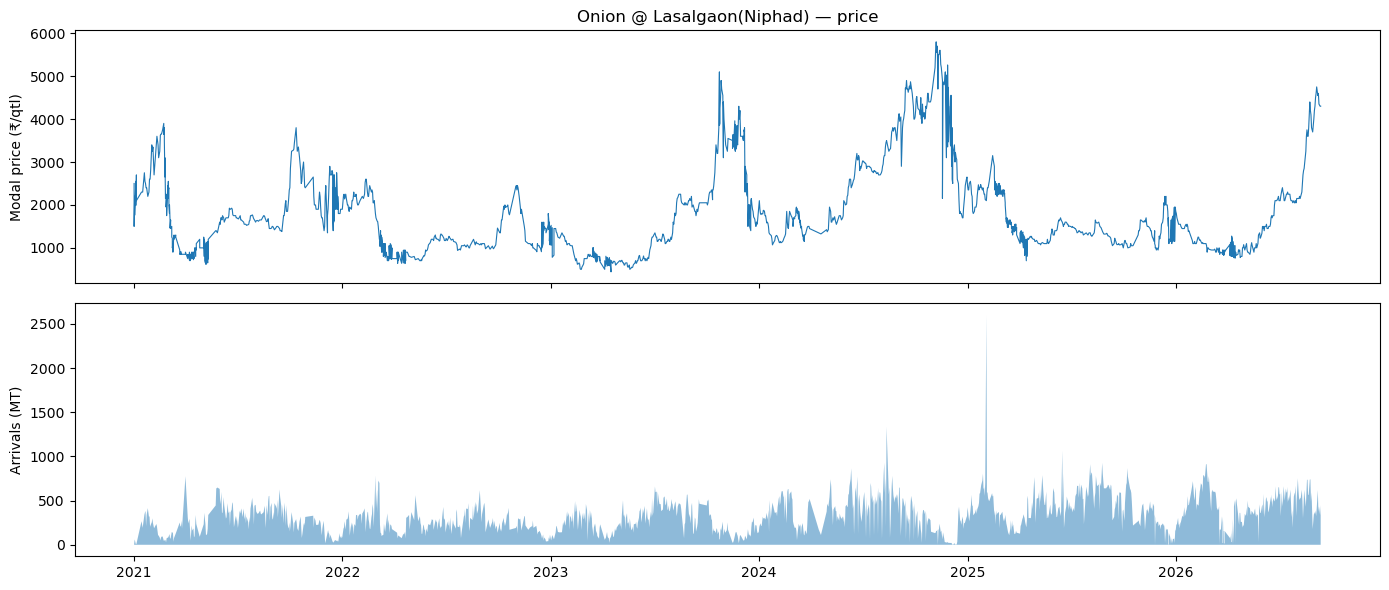

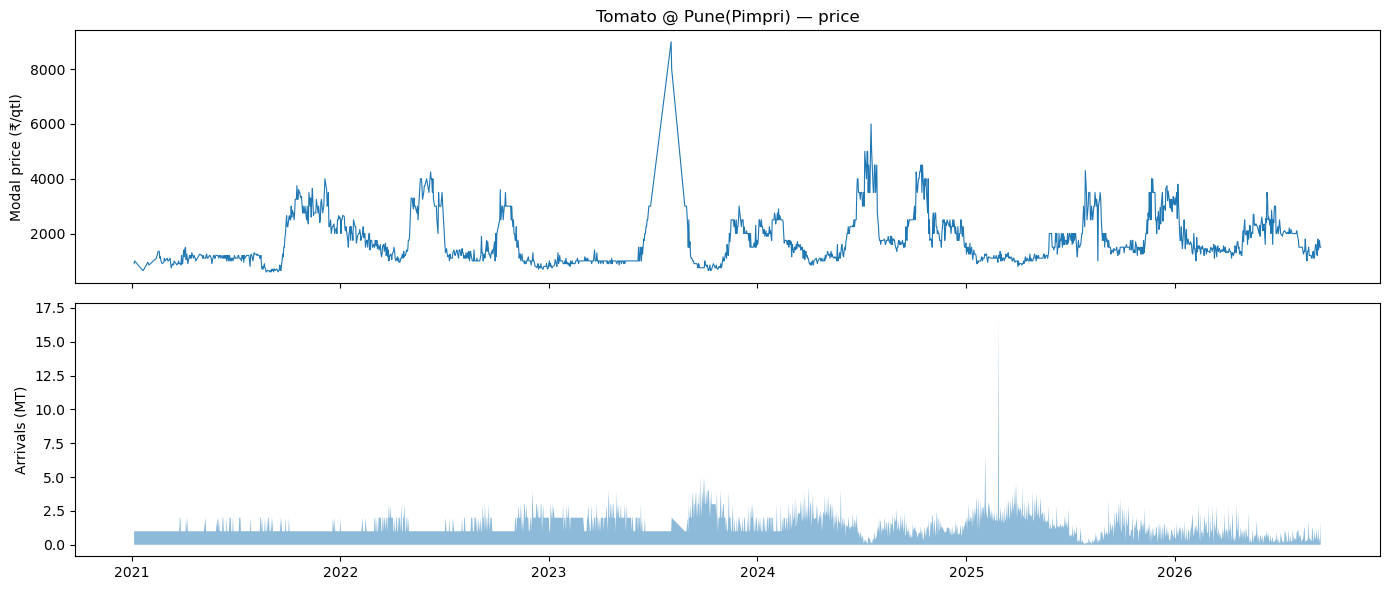

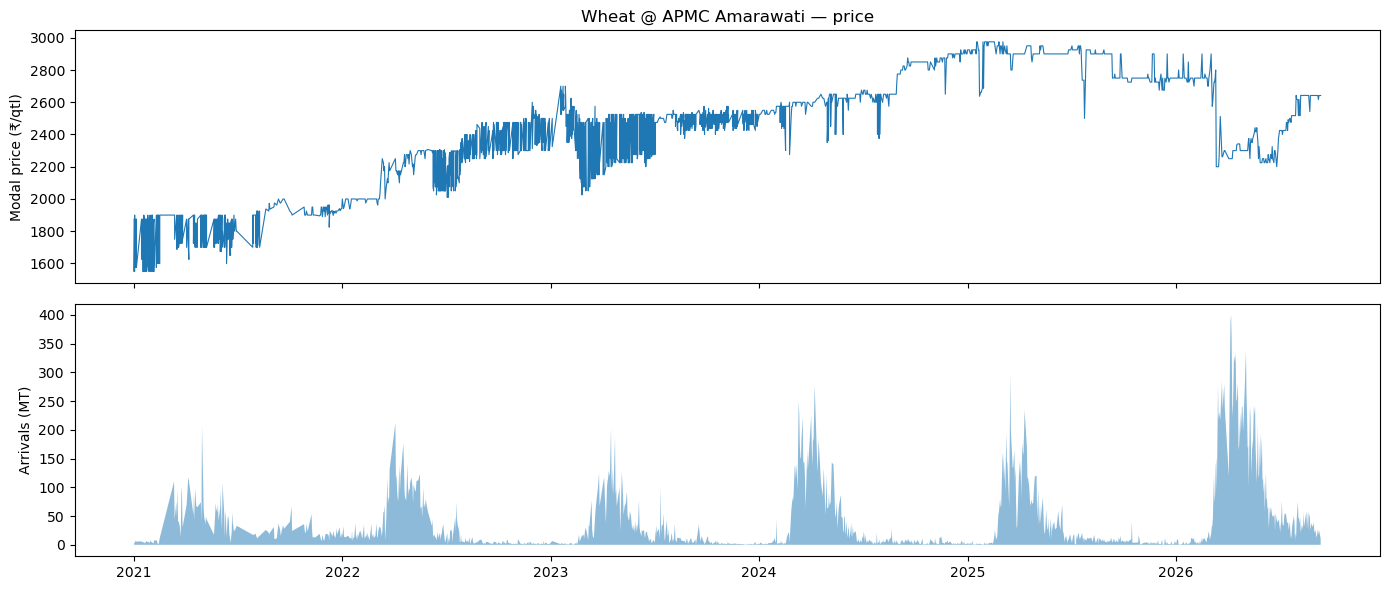

In [ ]:

def plot_series(market, commodity, df, min_days=500):
    s = df[(df.market_name == market) & (df.commodity_name == commodity)].sort_values("report_date")
    if len(s) < min_days: return
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(s["report_date"], s["modal_price"], lw=0.8)
    axes[0].set_ylabel("Modal price (₹/qtl)")
    axes[0].set_title(f"{commodity} @ {market} — price")
    axes[1].fill_between(s["report_date"], 0, s["arrivals"], alpha=0.5)
    axes[1].set_ylabel("Arrivals (MT)")
    plt.tight_layout(); plt.show()

# Run for 6-8 key pairs
for m, c in [("Lasalgaon(Niphad)", "Onion"),
             ("APMC Nashik", "Onion"),
             ("Pune(Pimpri)", "Tomato"),
             ("APMC Latur", "Soyabean"),
             ("APMC Akola", "Cotton"),
             ("APMC Amarawati", "Wheat")]:
    plot_series(m, c, df)

C:\Users\hp\AppData\Local\Temp\ipykernel_1924\1826578907.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  priority["month"] = priority["report_date"].dt.month


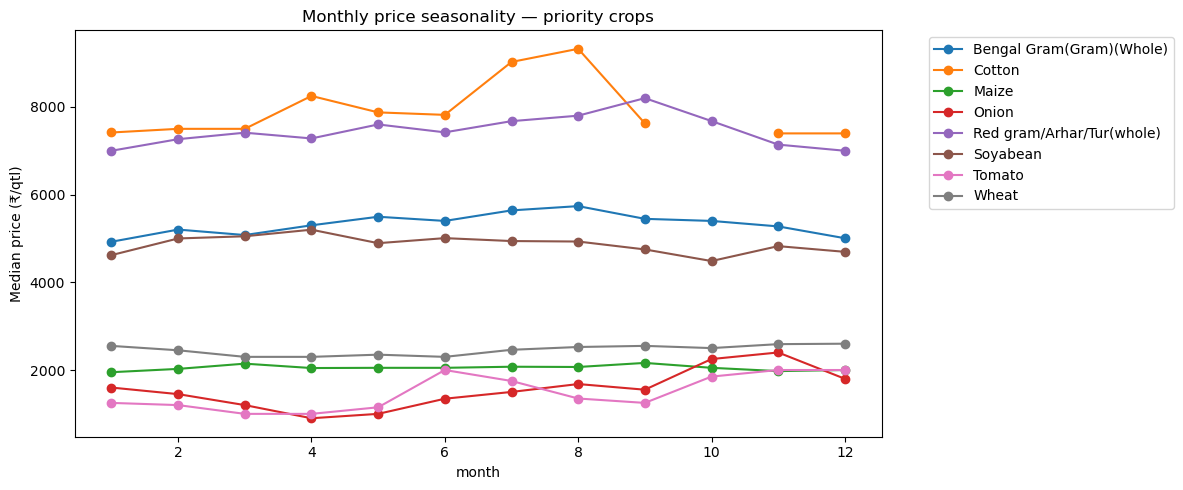

commodity_name  Bengal Gram(Gram)(Whole)  Cotton   Maize    Onion  \
month                                                               
1                                 4950.0  4639.0  1913.0   2600.0   
2                                 7277.0  4938.0  2300.0   3650.0   
3                                 5720.0  3488.0  1445.0   2150.0   
4                                 7550.0  3875.0  2050.0   1359.0   
5                                 5812.0  4163.0  2090.0   1850.0   
6                                 8234.0  2138.0  1500.0   2700.0   
7                                 7050.0  2250.0  2299.0  14450.0   
8                                10730.0    50.0  1300.0   5550.0   
9                                 9910.0     0.0  1340.0   4350.0   
10                               11600.0     NaN  1900.0   4850.0   
11                               10700.0  1575.0  1250.0   5900.0   
12                                6700.0  2785.0  1383.0   4200.0   

commodity_name  Red gram/Arhar/Tu

In [ ]:
# Monthly price seasonality per priority crop (state-wide average)
priority["month"] = priority["report_date"].dt.month
seasonality = priority.groupby(["commodity_name", "month"])["modal_price"].median().unstack(0)

fig, ax = plt.subplots(figsize=(12, 5))
seasonality.plot(ax=ax, marker="o")
ax.set_ylabel("Median price (₹/qtl)")
ax.set_title("Monthly price seasonality — priority crops")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout(); plt.show()

# Also: monthly price RANGE (not just median) — harvest vs lean season spread
price_range = priority.groupby(["commodity_name", "month"])["modal_price"].agg(["min", "max", "median"])
price_range["spread"] = price_range["max"] - price_range["min"]
print(price_range["spread"].unstack(0))

In [41]:
df_reliable.to_pickle("../processed/df_reliable.pkl")